Extended Data Figure 8 — Xu et al. 40-patient scATAC

Run from this folder. Set `PATH_TO_ATAC` to the PeakVI analysis root.

1. Naked panels
2. PowerPoint assembly


In [1]:
"""Export naked Xu scATAC panels and tick fractions for PowerPoint.

Reads the lineage-filtered PeakVI object and per-patient gap table from
ATAC_Data_New_Analysis (override with PATH_TO_ATAC). Does not load the
peak matrix — only obs + ForceAtlas coordinates via h5py.
"""

from __future__ import annotations

import json
import os
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

OUT = Path.cwd()
PANEL_DIR = OUT / "naked_panels"

DPI = 300
SCATTER_IN = 2.58
CBAR_W_IN = 0.135
C_W_IN = 5.55
C_H_IN = 2.30

DATA_ROOT = Path(
    os.environ.get(
        "PATH_TO_ATAC",
        str(Path.cwd().parents[2] / "ATAC_Data_New_Analysis"),
    )
)
H5AD = DATA_ROOT / "outputs/lineage_filter/joint/joint_PeakVI_refined.h5ad"
GAP = DATA_ROOT / "outputs/lineage_filter/joint/per_sample_openness_gap_refined.csv"


def _decode_uns(val):
    v = val[()] if hasattr(val, "__getitem__") else val
    if isinstance(v, bytes):
        return v.decode()
    if isinstance(v, np.generic):
        return v.item()
    return v


def load_plot_data():
    with h5py.File(H5AD, "r") as f:
        fa = np.array(f["obsm"]["X_draw_graph_fa"])
        n_peaks = np.array(f["obs"]["n_peaks"], dtype=float)
        dpt = np.array(f["obs"]["dpt_pseudotime"], dtype=float)
        n_obs = int(n_peaks.size)
        leiden = float(_decode_uns(f["uns"]["leiden_resolution"]))
        root = str(_decode_uns(f["uns"]["root_cluster"]))
    gap = pd.read_csv(GAP)
    return fa, n_peaks, dpt, n_obs, leiden, root, gap


def square_limits(fa, pad=1.04):
    x, y = fa[:, 0], fa[:, 1]
    cx = 0.5 * (x.min() + x.max())
    cy = 0.5 * (y.min() + y.max())
    span = 0.5 * pad * max(x.max() - x.min(), y.max() - y.min())
    return (cx - span, cx + span), (cy - span, cy + span)


def style_embed(ax, xlim, ylim):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_facecolor("white")


def frac_mapper(fig, ax):
    fig.canvas.draw()
    inv = fig.transFigure.inverted()

    def frac(data_x, data_y):
        px, py = ax.transData.transform((data_x, data_y))
        fx, fy = inv.transform((px, py))
        return float(fx), float(1.0 - fy)

    return frac


def save_scatter(path, fa, color, cmap, norm, xlim, ylim, order=None):
    if order is None:
        order = np.arange(fa.shape[0])
    fig, ax = plt.subplots(figsize=(SCATTER_IN, SCATTER_IN), dpi=DPI)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(0, 0, 1, 1)
    ax.set_position([0.0, 0.0, 1.0, 1.0])
    ax.scatter(
        fa[order, 0],
        fa[order, 1],
        c=color[order],
        s=1.35,
        cmap=cmap,
        norm=norm,
        linewidths=0,
        rasterized=True,
    )
    style_embed(ax, xlim, ylim)
    ax.set_position([0.0, 0.0, 1.0, 1.0])
    fig.savefig(path, dpi=DPI, facecolor="white", bbox_inches=None, pad_inches=0)
    plt.close(fig)


def save_cbar(path, cmap, norm, ticks):
    fig, ax = plt.subplots(figsize=(CBAR_W_IN, SCATTER_IN), dpi=DPI)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(0, 0, 1, 1)
    ax.set_position([0.0, 0.0, 1.0, 1.0])
    cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation="vertical")
    cb.set_ticks(ticks)
    cb.set_ticklabels([])
    cb.outline.set_linewidth(0.4)
    ax.tick_params(length=2.0, width=0.5, pad=0, labelleft=False, labelright=False)
    ax.set_position([0.0, 0.0, 1.0, 1.0])
    frac = frac_mapper(fig, ax)
    tick_pos = []
    for t in ticks:
        _fx, ftop = frac(0.5, t)
        tick_pos.append({"label": str(int(t)), "frac_top": ftop})
    fig.savefig(path, dpi=DPI, facecolor="white", bbox_inches=None, pad_inches=0)
    plt.close(fig)
    return tick_pos


def bootstrap_median_ci(values, n=4000, seed=0):
    rng = np.random.default_rng(seed)
    v = np.asarray(values, float)
    boots = [np.median(rng.choice(v, len(v), replace=True)) for _ in range(n)]
    return float(np.median(v)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))



def main():
    PANEL_DIR.mkdir(exist_ok=True)
    for old in PANEL_DIR.glob("*.png"):
        old.unlink()

    mpl.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
            "axes.linewidth": 0.5,
            "xtick.major.width": 0.5,
            "ytick.major.width": 0.5,
            "xtick.major.size": 2.0,
            "ytick.major.size": 2.0,
            "pdf.fonttype": 42,
        }
    )

    fa, n_peaks, dpt, n_obs, leiden, root, gap = load_plot_data()
    xlim, ylim = square_limits(fa)

    # (a) n_peaks — full observed range, round colourbar
    vmin_a, vmax_a = 0.0, 16000.0
    ticks_a = [0, 4000, 8000, 12000, 16000]
    norm_a = Normalize(vmin=vmin_a, vmax=vmax_a)
    save_scatter(
        PANEL_DIR / "a_scatter.png",
        fa,
        n_peaks,
        "viridis",
        norm_a,
        xlim,
        ylim,
        order=np.argsort(n_peaks),
    )
    cbar_ticks_a = save_cbar(PANEL_DIR / "a_cbar.png", mpl.cm.viridis, norm_a, ticks_a)

    # (b) DPT jet, clipped at 90th percentile
    dpt90 = float(np.nanpercentile(dpt, 90))
    dpt_clip = np.clip(dpt, 0.0, dpt90)
    norm_b = Normalize(vmin=0.0, vmax=dpt90)
    save_scatter(
        PANEL_DIR / "b_scatter.png",
        fa,
        dpt_clip,
        "jet",
        norm_b,
        xlim,
        ylim,
        order=np.argsort(dpt_clip),
    )
    cbar_ticks_b = save_cbar(
        PANEL_DIR / "b_cbar.png", mpl.cm.jet, norm_b, [0.0, dpt90]
    )
    cbar_ticks_b[0]["label"] = "Low"
    cbar_ticks_b[1]["label"] = "High"

    # (c) per-patient gap, ranked ascending so the series rises left → right
    pcts = gap["pct_diff_top_vs_next"].to_numpy(dtype=float)
    med, lo, hi = bootstrap_median_ci(pcts)
    yv = np.sort(pcts)
    x = np.arange(1, len(yv) + 1)
    yticks = [0.0, 10.0, 20.0, 30.0, 40.0]
    xticks = [1, 10, 20, 30, 40]

    fig, ax = plt.subplots(figsize=(C_W_IN, C_H_IN), dpi=DPI)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    # Inset so left/bottom spines and outward ticks are not clipped.
    ax.set_position([0.10, 0.16, 0.88, 0.80])
    ax.axhline(med, color="#15803D", lw=1.15, ls="--", zorder=1)
    ax.scatter(
        x,
        yv,
        s=26,
        c="#1D4ED8",
        zorder=3,
        edgecolors="white",
        linewidths=0.35,
    )
    ax.set_xlim(0.5, 40.5)
    ax.set_ylim(0.0, 40.0)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels([f"{int(t)}%" for t in yticks])
    ax.tick_params(
        axis="both",
        which="both",
        labelbottom=True,
        labelleft=True,
        labelsize=7,
        length=2.2,
        width=0.5,
        direction="out",
        pad=2,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.25, color="0.88")
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)
    frac = frac_mapper(fig, ax)
    ytick_pos = []
    for t in yticks:
        _fx, ftop = frac(ax.get_xlim()[0], t)
        ytick_pos.append({"label": f"{int(t)}%", "frac_top": ftop})
    xtick_pos = []
    for t in xticks:
        fleft, _fy = frac(float(t), 0.0)
        xtick_pos.append({"label": str(t), "frac_left": fleft})
    _fx, med_top = frac(ax.get_xlim()[1], med)
    fig.savefig(
        PANEL_DIR / "c.png",
        dpi=DPI,
        facecolor="white",
        bbox_inches=None,
        pad_inches=0,
    )
    plt.close(fig)

    n_pos = int((pcts > 0).sum())
    n_pat = int(len(pcts))
    n_gt5 = int((pcts > 5.0).sum())
    caption = (
        "Figure. A shared high-accessibility state is recovered from public T-ALL "
        "scATAC-seq. Cells from 40 Xu et al. samples were lineage-filtered "
        f"(B cell, NK and erythroid removed; n = {n_obs:,}) and jointly embedded "
        f"with PeakVI and ForceAtlas2 (Leiden resolution {leiden:g}). "
        "(a) Chromatin accessibility (ATAC peaks per cell). "
        "(b) Diffusion pseudotime rooted at the tip cell of the most-open cluster "
        f"(cluster {root}; 4,036 cells; mean ≈ 12,833 peaks); colour is jet and "
        "clipped at the 90th percentile. "
        "(c) Within-patient gap relative to the next most accessible cluster with "
        "≥10 cells (patients ranked by this difference). "
        f"{n_pos}/{n_pat} patients positive; >5% in {n_gt5}/{n_pat}; "
        f"median +{med:.1f}% (bootstrap 95% CI {lo:.1f}–{hi:.1f}%)."
    )

    layout = {
        "width_in": 7.5,
        "height_in": 9.86,
        "caption": caption,
        "stats": {
            "n_obs": n_obs,
            "leiden": leiden,
            "root": root,
            "n_pos": n_pos,
            "n_pat": n_pat,
            "median": med,
            "ci_lo": lo,
            "ci_hi": hi,
            "range_min": float(pcts.min()),
            "range_max": float(pcts.max()),
        },
        "a": {
            "scatter": "naked_panels/a_scatter.png",
            "cbar": "naked_panels/a_cbar.png",
            "cbar_ticks": cbar_ticks_a,
            "title": "Chromatin accessibility",
            "subtitle": "n_peaks",
        },
        "b": {
            "scatter": "naked_panels/b_scatter.png",
            "cbar": "naked_panels/b_cbar.png",
            "cbar_ticks": cbar_ticks_b,
            "title": "Pseudotime (root at embedding tip)",
        },
        "c": {
            "file": "naked_panels/c.png",
            "yticks": ytick_pos,
            "xticks": xtick_pos,
            "median_frac_top": med_top,
            "median_label": f"median +{med:.0f}%",
            "title": "Consistency across 40 patients",
            "stat_pos": f"{n_pos}/{n_pat} patients positive",
        },
    }
    (OUT / "pptx_layout.json").write_text(json.dumps(layout, indent=2))
    (OUT / "figure_caption.txt").write_text(caption + "\n")
    print(f"Wrote naked panels → {PANEL_DIR}")
    print(f"median +{med:.1f}%  {n_pos}/{n_pat} positive")
    print(f"n = {n_obs:,}  Leiden {leiden:g}  root cluster {root}")


main()


Wrote naked panels → Figures/Extended_Data_Figure_Xu_scATAC/naked_panels
median +19%  40/40 positive
n = 50,244  Leiden 0.91  root cluster 2


In [2]:
"""Nature double-column PowerPoint: naked plots + Helvetica text boxes.

Print size 183 × 195 mm (Nature two-column width; height fitted to panels).
Panel letters 8 pt bold. All other text 5–7 pt. Line art stays in the PNGs.
"""

from __future__ import annotations

import json
from pathlib import Path

from pptx import Presentation
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx.util import Emu, Pt

OUT = Path.cwd()
EMU_PER_MM = 36000
GREEN = RGBColor(0x15, 0x80, 0x3D)
BLACK = RGBColor(0, 0, 0)
GRAY = RGBColor(0x44, 0x44, 0x44)

# Nature two-column
W = 183.0
H = 195.0


def mm(x):
    return Emu(int(round(x * EMU_PER_MM)))


def add_text(
    slide,
    x,
    y,
    w,
    h,
    text,
    size=6,
    bold=False,
    align="center",
    rotation=0,
    color=BLACK,
    anchor="ctr",
):
    box = slide.shapes.add_textbox(mm(x), mm(y), mm(w), mm(h))
    if rotation:
        box.rotation = rotation
    tf = box.text_frame
    tf.word_wrap = True
    tf.auto_size = None
    for m in ("margin_left", "margin_right", "margin_top", "margin_bottom"):
        setattr(tf, m, Pt(0))
    try:
        tf._txBody.bodyPr.set("anchor", anchor)
    except Exception:
        pass
    align_enum = {
        "center": PP_ALIGN.CENTER,
        "left": PP_ALIGN.LEFT,
        "right": PP_ALIGN.RIGHT,
    }[align]
    for i, line in enumerate(str(text).split("\n")):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.alignment = align_enum
        run = p.add_run()
        run.text = line
        run.font.size = Pt(size)
        run.font.bold = bold
        run.font.name = "Helvetica"
        run.font.color.rgb = color
    return box


def add_caption(slide, x, y, w, h, caption):
    """Nature-style legend: bold 'Figure.' then roman body."""
    box = slide.shapes.add_textbox(mm(x), mm(y), mm(w), mm(h))
    tf = box.text_frame
    tf.word_wrap = True
    tf.auto_size = None
    for m in ("margin_left", "margin_right", "margin_top", "margin_bottom"):
        setattr(tf, m, Pt(0))
    try:
        tf._txBody.bodyPr.set("anchor", "t")
    except Exception:
        pass
    p = tf.paragraphs[0]
    p.alignment = PP_ALIGN.LEFT
    body = caption
    if body.startswith("Figure. "):
        body = body[len("Figure. ") :]
    run = p.add_run()
    run.text = "Figure. "
    run.font.size = Pt(6)
    run.font.bold = True
    run.font.name = "Helvetica"
    run.font.color.rgb = BLACK
    run = p.add_run()
    run.text = body
    run.font.size = Pt(6)
    run.font.bold = False
    run.font.name = "Helvetica"
    run.font.color.rgb = BLACK
    return box


def add_rotated(slide, cx, cy, w, h, text, size):
    return add_text(slide, cx - w / 2.0, cy - h / 2.0, w, h, text, size=size, rotation=270)


def place_cbar_ticks(slide, ticks, cbar_x, plot_y, cbar_w, plot_h, tick_w):
    box_h = 3.0
    for tick in ticks:
        yy = plot_y + plot_h * float(tick["frac_top"]) - box_h / 2.0
        yy = min(max(yy, plot_y), plot_y + plot_h - box_h)
        add_text(
            slide,
            cbar_x + cbar_w + 0.35,
            yy,
            tick_w - 0.3,
            box_h,
            tick["label"],
            size=5,
            align="left",
        )


def main():
    layout = json.loads((OUT / "pptx_layout.json").read_text())
    prs = Presentation()
    prs.slide_width = mm(W)
    prs.slide_height = mm(H)
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    ML, MR, MT = 7.0, 3.5, 4.0
    letter_w = 4.6
    title_h = 7.2
    cbar_gap = 1.2
    cbar_w = 2.7
    cbar_tick_w = 9.2
    gap_ab = 4.0
    gap_row = 5.0

    col_w = (W - ML - MR - gap_ab) / 2.0
    side = col_w - letter_w - cbar_gap - cbar_w - cbar_tick_w

    for i, key in enumerate(("a", "b")):
        pan = layout[key]
        col_x = ML + i * (col_w + gap_ab)
        plot_x = col_x + letter_w
        plot_y = MT + title_h
        cbar_x = plot_x + side + cbar_gap

        add_text(slide, col_x, MT, letter_w, 5.0, key, size=8, bold=True, align="left", anchor="t")
        add_text(
            slide, plot_x, MT, side, title_h - 0.2, pan["title"],
            size=7, bold=True, align="center", anchor="ctr",
        )

        slide.shapes.add_picture(str(OUT / pan["scatter"]), mm(plot_x), mm(plot_y), mm(side), mm(side))
        slide.shapes.add_picture(str(OUT / pan["cbar"]), mm(cbar_x), mm(plot_y), mm(cbar_w), mm(side))
        place_cbar_ticks(slide, pan["cbar_ticks"], cbar_x, plot_y, cbar_w, side, cbar_tick_w)

    c = layout["c"]
    c_top = MT + title_h + side + gap_row
    ytick_w = 10.0
    ylabel_w = 11.0
    c_title_h = 5.8
    xtick_h = 3.8
    xlabel_h = 4.8
    c_plot_h = 48.0
    c_plot_x = ML + letter_w + ylabel_w + ytick_w
    c_plot_w = W - MR - c_plot_x
    c_plot_y = c_top + c_title_h

    add_text(slide, ML, c_top, letter_w, 5.0, "c", size=8, bold=True, align="left", anchor="t")
    add_text(
        slide, c_plot_x, c_top, c_plot_w, c_title_h, c["title"],
        size=7, bold=True, align="center", anchor="b",
    )
    add_text(
        slide, c_plot_x + 1.0, c_plot_y + 1.0, 42.0, 3.2, c["stat_pos"],
        size=5, align="left", color=GREEN, bold=True, anchor="t",
    )

    slide.shapes.add_picture(str(OUT / c["file"]), mm(c_plot_x), mm(c_plot_y), mm(c_plot_w), mm(c_plot_h))

    # Panel c PNG already has the axis numbers.

    add_rotated(
        slide,
        cx=ML + letter_w + ylabel_w / 2.0,
        cy=c_plot_y + c_plot_h / 2.0,
        w=46.0,
        h=10.5,
        text="Most-open vs next cluster\n(mean ATAC peaks)",
        size=5,
    )
    add_text(
        slide, c_plot_x, c_plot_y + c_plot_h + xtick_h, c_plot_w, xlabel_h,
        "Patients, ranked by within-patient difference",
        size=6, align="center", anchor="t",
    )

    med_box_h = 3.0
    med_y = c_plot_y + c_plot_h * float(c["median_frac_top"]) - med_box_h - 0.3
    add_text(
        slide, c_plot_x + c_plot_w - 28.0, med_y, 27.0, med_box_h,
        c["median_label"], size=5, align="right", color=GREEN, bold=True, anchor="b",
    )

    cap_y = c_plot_y + c_plot_h + xtick_h + xlabel_h + 2.0
    add_caption(slide, ML, cap_y, W - ML - MR, H - cap_y - 3.0, layout["caption"])

    out = OUT / "Xu_scATAC_cohort.pptx"
    prs.save(str(out))
    print(f"Wrote {out}")
    print(f"  Nature {W:.0f} × {H:.0f} mm; FA {side:.1f} mm square; c {c_plot_w:.1f} × {c_plot_h:.1f} mm")


main()


Wrote Figures/Extended_Data_Figure_Xu_scATAC/Xu_scATAC_cohort.pptx
  Nature 183 × 195 mm; FA 66.5 mm square; c 146.9 × 48.0 mm


## Preview

The three panels this notebook just wrote, so they are visible without opening the PowerPoint.


a - ATAC peaks per cell


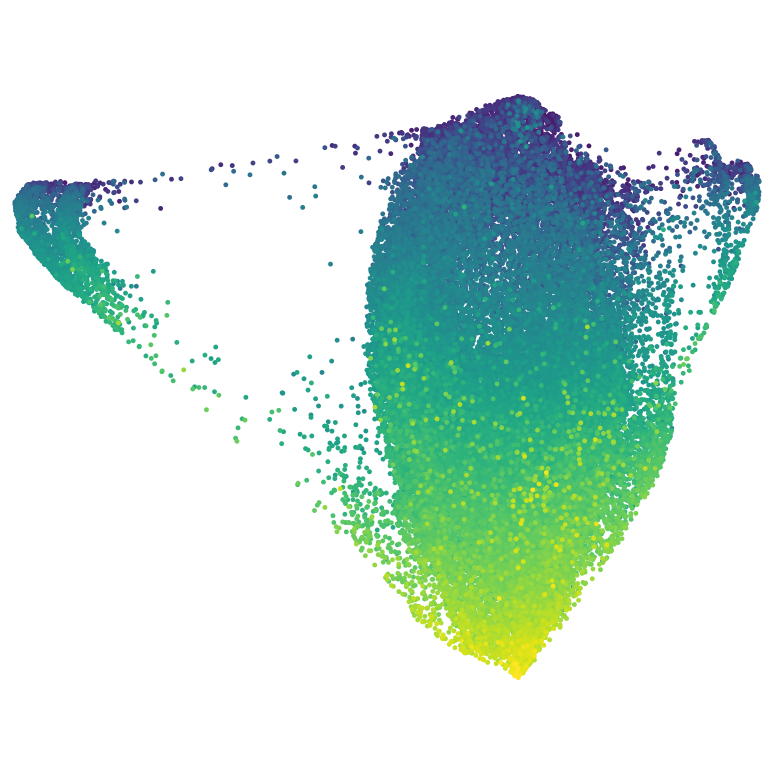

b - diffusion pseudotime from the most-open cluster


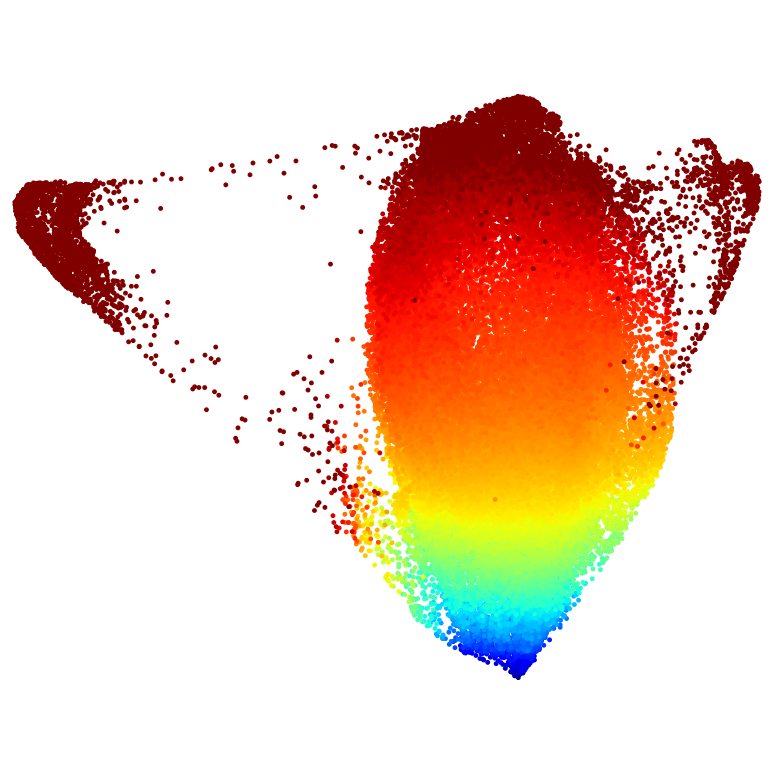

c - within-patient gap vs the next cluster


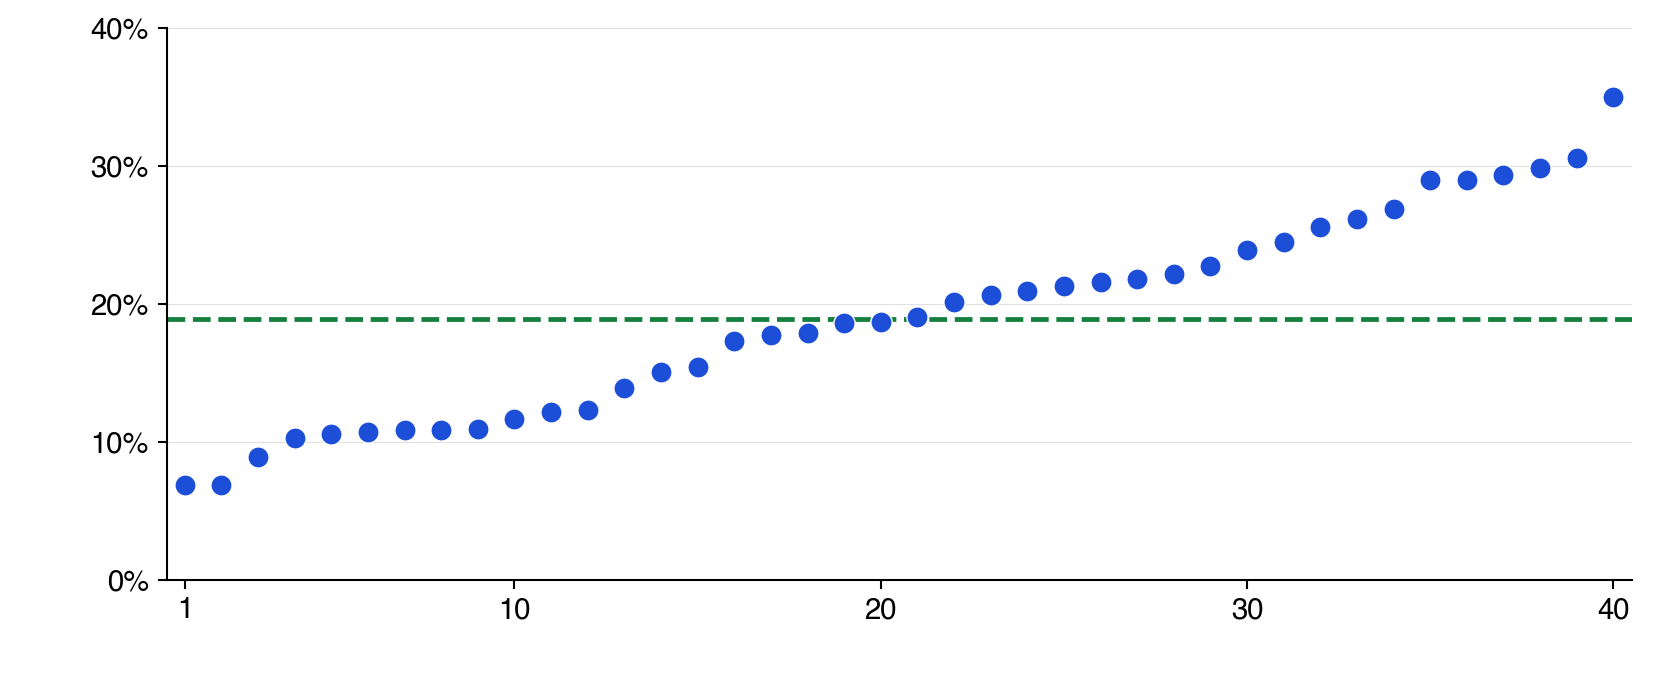

In [3]:
from pathlib import Path

from IPython.display import Image, display

# cell 1 switches matplotlib to Agg, so show the saved panels directly
for name, caption in [
    ("a_scatter.png", "a - ATAC peaks per cell"),
    ("b_scatter.png", "b - diffusion pseudotime from the most-open cluster"),
    ("c.png", "c - within-patient gap vs the next cluster"),
]:
    print(caption)
    display(Image(filename=str(Path.cwd() / "naked_panels" / name)))
